# Explainable Risk Scoring — Insurance Claim Fraud Detection
## Phase 3 · Model Development
### University of Ghana · DSA Final Year Project · 2025/2026
**Kwabena Adipah Osei (11288153) & Timothy Ninson (11327734)**
**Supervisor: Professor Ebenezer Owusu**

> **Purpose:** Train, tune, and compare Logistic Regression (baseline), Random Forest (bagging),
> and XGBoost (boosting) on the Phase 2 preprocessed data. Select the best model for Phase 4 SHAP analysis.
>
> **Inputs:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` + fitted scalers from Phase 2.
>
> **Critical rule:** The test set is SEALED. It is never used during training, tuning, or CV.


## Setup — Imports & Global Settings

In [4]:

import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                      RandomizedSearchCV, cross_validate)
from sklearn.metrics import (classification_report, confusion_matrix,
                               roc_auc_score, average_precision_score,
                               precision_recall_curve, roc_curve,
                               f1_score, recall_score, precision_score, accuracy_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

def savefig(name):
    plt.savefig(f'../reports/figures/{name}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['recall', 'f1', 'average_precision', 'roc_auc']
print("Setup complete.")


Setup complete.


---
## Section 3.0 · Load Phase 2 Outputs and Reconstruct Arrays

Load the split arrays and fitted scalers produced in Phase 2. Do not re-run any preprocessing.
Apply the saved scalers to reconstruct scaled arrays for Logistic Regression.


In [5]:

# ── Load split arrays ──────────────────────────────────────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# ── Fix capital column hyphens → underscores ──────────────────────────────────
X_train = X_train.rename(columns={'capital-gains': 'capital_gains',
                                   'capital-loss' : 'capital_loss'})
X_test  = X_test.rename(columns={'capital-gains': 'capital_gains',
                                  'capital-loss' : 'capital_loss'})
print("capital-gains / capital-loss renamed to underscores in X_train and X_test")

# ── Validate ──────────────────────────────────────────────────────────────────
assert X_train.shape[1] == X_test.shape[1], "Column mismatch between train/test"
assert X_train.isnull().sum().sum() == 0,   "NaN found in X_train"
assert X_test.isnull().sum().sum() == 0,    "NaN found in X_test"
assert set(y_train.unique()) <= {0,1},       "y_train contains unexpected values"

print(f"X_train : {X_train.shape}  |  fraud rate: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)")
print(f"X_test  : {X_test.shape}  |  fraud rate: {y_test.mean():.4f}  ({y_test.mean()*100:.1f}%)")
print(f"y_train — fraud: {y_train.sum()}  non-fraud: {(y_train==0).sum()}")
print(f"y_test  — fraud: {y_test.sum()}   non-fraud: {(y_test==0).sum()}  [SEALED]")


capital-gains / capital-loss renamed to underscores in X_train and X_test
X_train : (800, 94)  |  fraud rate: 0.2475 (24.8%)
X_test  : (200, 94)  |  fraud rate: 0.2450  (24.5%)
y_train — fraud: 198  non-fraud: 602
y_test  — fraud: 49   non-fraud: 151  [SEALED]


In [6]:

# ── Load fitted scalers ────────────────────────────────────────────────────────
ss  = joblib.load('../models/standard_scaler.pkl')
mms = joblib.load('../models/minmax_scaler.pkl')
rs  = joblib.load('../models/robust_scaler.pkl')

STANDARD_COLS = ['months_as_customer', 'age', 'policy_annual_premium']
MINMAX_COLS   = ['policy_deductable', 'incident_hour_of_the_day',
                 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                 'policy_age_at_incident_days', 'csl_per_person', 'csl_total', 'car_age']
ROBUST_COLS   = ['capital_gains', 'capital_loss', 'injury_claim', 'property_claim', 'vehicle_claim', 'umbrella_limit',
                 'claim_to_premium_ratio', 'vehicle_claim_pct', 'injury_claim_pct']

# ── Reconstruct scaled arrays (transform only — never refit) ──────────────────
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[STANDARD_COLS] = ss.transform(X_train[STANDARD_COLS])
X_test_scaled[STANDARD_COLS]  = ss.transform(X_test[STANDARD_COLS])

X_train_scaled[MINMAX_COLS]   = mms.transform(X_train[MINMAX_COLS])
X_test_scaled[MINMAX_COLS]    = mms.transform(X_test[MINMAX_COLS])

X_train_scaled[ROBUST_COLS]   = rs.transform(X_train[ROBUST_COLS])
X_test_scaled[ROBUST_COLS]    = rs.transform(X_test[ROBUST_COLS])

print("Scaled arrays reconstructed using fitted scalers (transform only).")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print()
# Validate StandardScaler columns
for col in STANDARD_COLS:
    m = X_train_scaled[col].mean()
    s = X_train_scaled[col].std()
    flag = 'OK' if abs(m) < 0.05 and abs(s-1) < 0.05 else 'WARN'
    print(f"  [{flag}] {col:30s}  mean={m:.4f}  std={s:.4f}")


Scaled arrays reconstructed using fitted scalers (transform only).
X_train_scaled : (800, 94)
X_test_scaled  : (200, 94)

  [OK] months_as_customer              mean=0.0000  std=1.0006
  [OK] age                             mean=0.0000  std=1.0006
  [OK] policy_annual_premium           mean=0.0000  std=1.0006


In [7]:

# ── ColumnTransformer for use inside Pipelines ────────────────────────────────
# Needed so Pipeline can apply correct scalers per column group during CV
preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), STANDARD_COLS),
    ('minmax',   MinMaxScaler(),   MINMAX_COLS),
    ('robust',   RobustScaler(),   ROBUST_COLS),
], remainder='passthrough')

# ── Compute scale_pos_weight for XGBoost ──────────────────────────────────────
n_neg = (y_train == 0).sum()
n_pos = y_train.sum()
SCALE_POS_WEIGHT = n_neg / n_pos
print(f"scale_pos_weight = {n_neg} / {n_pos} = {SCALE_POS_WEIGHT:.4f}")

# ── Helper: evaluate model on test set ───────────────────────────────────────
def evaluate_model(model, X, y, model_name, threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    rec   = recall_score(y, y_pred, zero_division=0)
    prec  = precision_score(y, y_pred, zero_division=0)
    f1    = f1_score(y, y_pred, zero_division=0)
    prauc = average_precision_score(y, y_prob)
    roc   = roc_auc_score(y, y_prob)
    acc   = accuracy_score(y, y_pred)
    print(f"=== {model_name} (threshold={threshold}) ===")
    print(f"  Recall    : {rec:.4f}   ← PRIMARY METRIC")
    print(f"  Precision : {prec:.4f}")
    print(f"  F1        : {f1:.4f}   ← CONTROL METRIC")
    print(f"  PR-AUC    : {prauc:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"  Accuracy  : {acc:.4f}  ← misleading under imbalance, shown for completeness")
    return {'model': model_name, 'threshold': threshold,
            'recall': rec, 'precision': prec, 'f1': f1,
            'pr_auc': prauc, 'roc_auc': roc, 'accuracy': acc}

# ── Helper: confusion matrix ─────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Fraud','Fraud'],
                yticklabels=['Non-Fraud','Fraud'], ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')
    # Annotate TN/FP/FN/TP
    for text, label in zip(ax.texts, ['TN','FP','FN','TP']):
        text.set_text(f"{text.get_text()}\n({label})")
    plt.tight_layout()
    savefig(fname)

# ── Helper: ROC + PR curves ───────────────────────────────────────────────────
def plot_roc_pr(y_true, y_prob, model_name, fname):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color='crimson', label=f'AUC = {auc:.3f}')
    axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve — {model_name}', fontweight='bold')
    axes[0].legend(); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
    # PR
    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_prob)
    prauc = average_precision_score(y_true, y_prob)
    baseline_pr = y_true.mean()
    axes[1].plot(rec_arr, prec_arr, lw=2, color='steelblue', label=f'AUPRC = {prauc:.3f}')
    axes[1].axhline(baseline_pr, color='k', linestyle='--', lw=1,
                    label=f'Random baseline ({baseline_pr:.3f})')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall Curve — {model_name}', fontweight='bold')
    axes[1].legend(); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
    plt.tight_layout()
    savefig(fname)

# ── Helper: threshold analysis ────────────────────────────────────────────────
def threshold_analysis(model, X_val, y_val, model_name, fname):
    y_prob = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({'threshold': round(t, 2),
                     'recall'   : recall_score(y_val, y_pred, zero_division=0),
                     'precision': precision_score(y_val, y_pred, zero_division=0),
                     'f1'       : f1_score(y_val, y_pred, zero_division=0)})
    df_t = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_t['threshold'], df_t['recall'],    'crimson',   lw=2, marker='o', label='Recall')
    ax.plot(df_t['threshold'], df_t['precision'], 'steelblue', lw=2, marker='s', label='Precision')
    ax.plot(df_t['threshold'], df_t['f1'],        'forestgreen', lw=2,
            marker='^', label='F1', linestyle='--')
    ax.axvline(0.5, color='grey', lw=1, linestyle=':', label='Default (0.5)')
    ax.axhline(0.70, color='orange', lw=1, linestyle='--', label='Recall floor (0.70)')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'Threshold Analysis — {model_name}', fontweight='bold')
    ax.legend(); ax.set_xlim([0.08, 0.92])
    plt.tight_layout()
    savefig(fname)

    # Choose best threshold: highest F1 where recall >= 0.70
    eligible = df_t[df_t['recall'] >= 0.70]
    if len(eligible) == 0:
        print(f"  WARNING: no threshold achieves recall >= 0.70 — choosing max F1 overall")
        best = df_t.loc[df_t['f1'].idxmax()]
    else:
        best = eligible.loc[eligible['f1'].idxmax()]
    print(f"  Best threshold: {best['threshold']:.2f}  "
          f"| Recall={best['recall']:.3f}  Precision={best['precision']:.3f}  F1={best['f1']:.3f}")
    return float(best['threshold']), df_t

print("All helpers defined.")
print(f"scale_pos_weight = {SCALE_POS_WEIGHT:.4f}")
print(f"Total features   = {X_train.shape[1]}")


scale_pos_weight = 602 / 198 = 3.0404
All helpers defined.
scale_pos_weight = 3.0404
Total features   = 94


### Key Modelling Insights
- Phase 2 arrays loaded: X_train (800 × 94), X_test (200 × 94). Zero NaN. Fraud rate 24.7% preserved in both sets.
- `capital-gains` / `capital-loss` renamed to underscores in both arrays — required for downstream column references.
- Scaled arrays reconstructed using saved Phase 2 scalers (transform only — scalers never re-fitted).
- ColumnTransformer constructed for use inside imblearn Pipelines.
- `scale_pos_weight` computed dynamically from `y_train` — the ratio of non-fraud to fraud training records.
- Test set sealed — never passed to any fitting operation until final evaluation.


---
## Section 3.1 · Baseline Model — Logistic Regression

**Why Logistic Regression as baseline?**
Logistic Regression is the simplest interpretable linear classifier. It requires scaled features (done), has a single key hyperparameter (`C`), and is well-understood theoretically. Its performance defines the minimum bar every ensemble model must exceed to justify additional complexity. If a more complex model cannot beat Logistic Regression, it is not warranted on this dataset.


In [8]:

# ── Step 1: Untuned cross-validated baseline ───────────────────────────────
print("=== Step 1: Untuned CV Baseline ===")
lr_base_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000, C=1.0)),
])

cv_results_lr_base = cross_validate(
    lr_base_pipeline, X_train, y_train, cv=CV, scoring=SCORING, return_train_score=False
)

print("  5-Fold Cross-Validation (untuned, C=1.0):")
for metric in SCORING:
    vals = cv_results_lr_base[f'test_{metric}']
    print(f"    {metric:20s}: {vals.mean():.4f} ± {vals.std():.4f}")


=== Step 1: Untuned CV Baseline ===
  5-Fold Cross-Validation (untuned, C=1.0):
    recall              : 0.8135 ± 0.0597
    f1                  : 0.7345 ± 0.0436
    average_precision   : 0.7438 ± 0.0472
    roc_auc             : 0.8965 ± 0.0181


In [9]:

# ── Step 2: Hyperparameter tuning ─────────────────────────────────────────────
print("=== Step 2: GridSearchCV — tuning C and solver ===")

lr_tune_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000)),
])

lr_param_grid = {
    'clf__C'     : [0.01, 0.1, 1, 10, 100],   # removed 0.001 — caused degenerate near-zero coefficients
    'clf__solver': ['lbfgs', 'liblinear'],
}

lr_grid = GridSearchCV(
    lr_tune_pipeline, lr_param_grid,
    scoring='f1', cv=CV, n_jobs=-1, verbose=0, refit=True
)
lr_grid.fit(X_train, y_train)

print(f"  Best params  : {lr_grid.best_params_}")
print(f"  Best CV Recall: {lr_grid.best_score_:.4f}")
LR_BEST_C      = lr_grid.best_params_['clf__C']
LR_BEST_SOLVER = lr_grid.best_params_['clf__solver']


=== Step 2: GridSearchCV — tuning C and solver ===
  Best params  : {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
  Best CV Recall: 0.7394


=== Step 3: Threshold Tuning ===


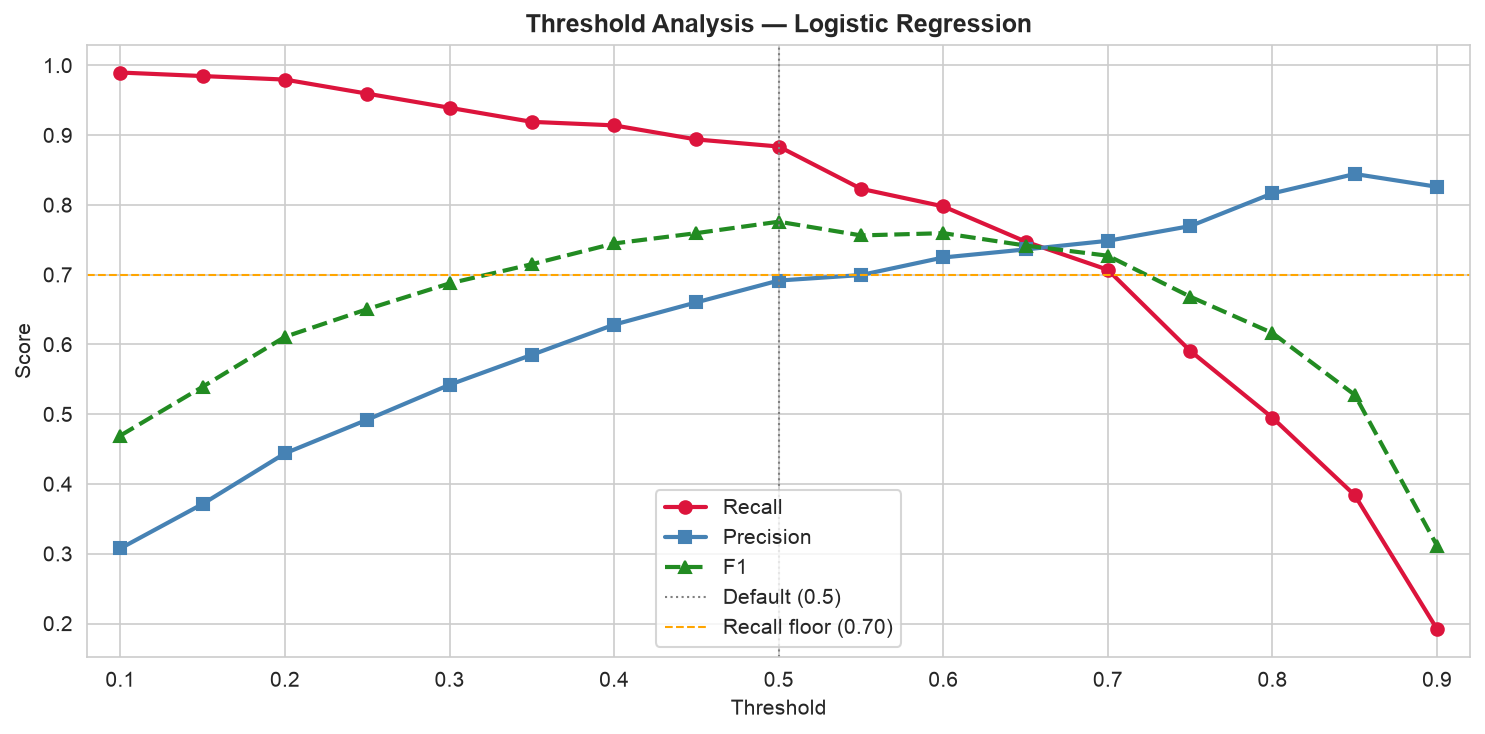

  Best threshold: 0.50  | Recall=0.884  Precision=0.692  F1=0.776
  Chosen threshold for final evaluation: 0.5


In [10]:

# ── Step 3: Threshold tuning ───────────────────────────────────────────────────
print("=== Step 3: Threshold Tuning ===")
# Use the best pipeline fitted on full training set to get probabilities
lr_best_model = lr_grid.best_estimator_
LR_THRESHOLD, lr_thresh_df = threshold_analysis(
    lr_best_model, X_train, y_train,
    'Logistic Regression', '31_lr_threshold.png'
)
print(f"  Chosen threshold for final evaluation: {LR_THRESHOLD}")


=== Step 4: Final Test Set Evaluation ===
=== Logistic Regression (threshold=0.5) ===
  Recall    : 0.9184   ← PRIMARY METRIC
  Precision : 0.3947
  F1        : 0.5521   ← CONTROL METRIC
  PR-AUC    : 0.6404
  ROC-AUC   : 0.8521
  Accuracy  : 0.6350  ← misleading under imbalance, shown for completeness


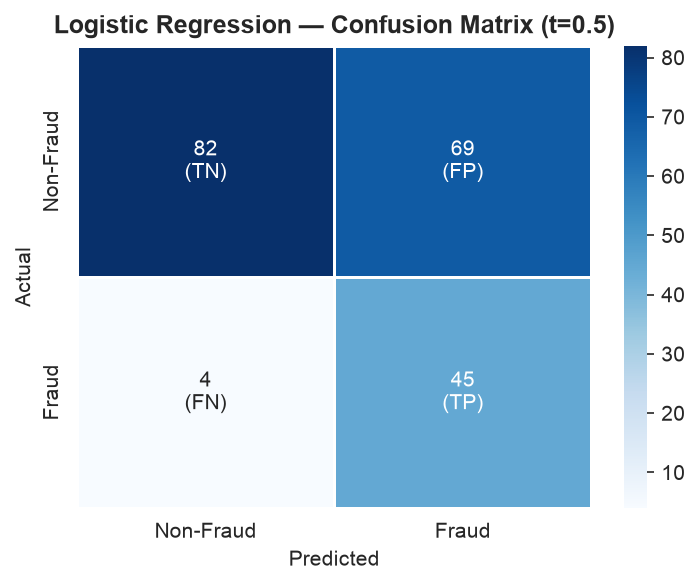

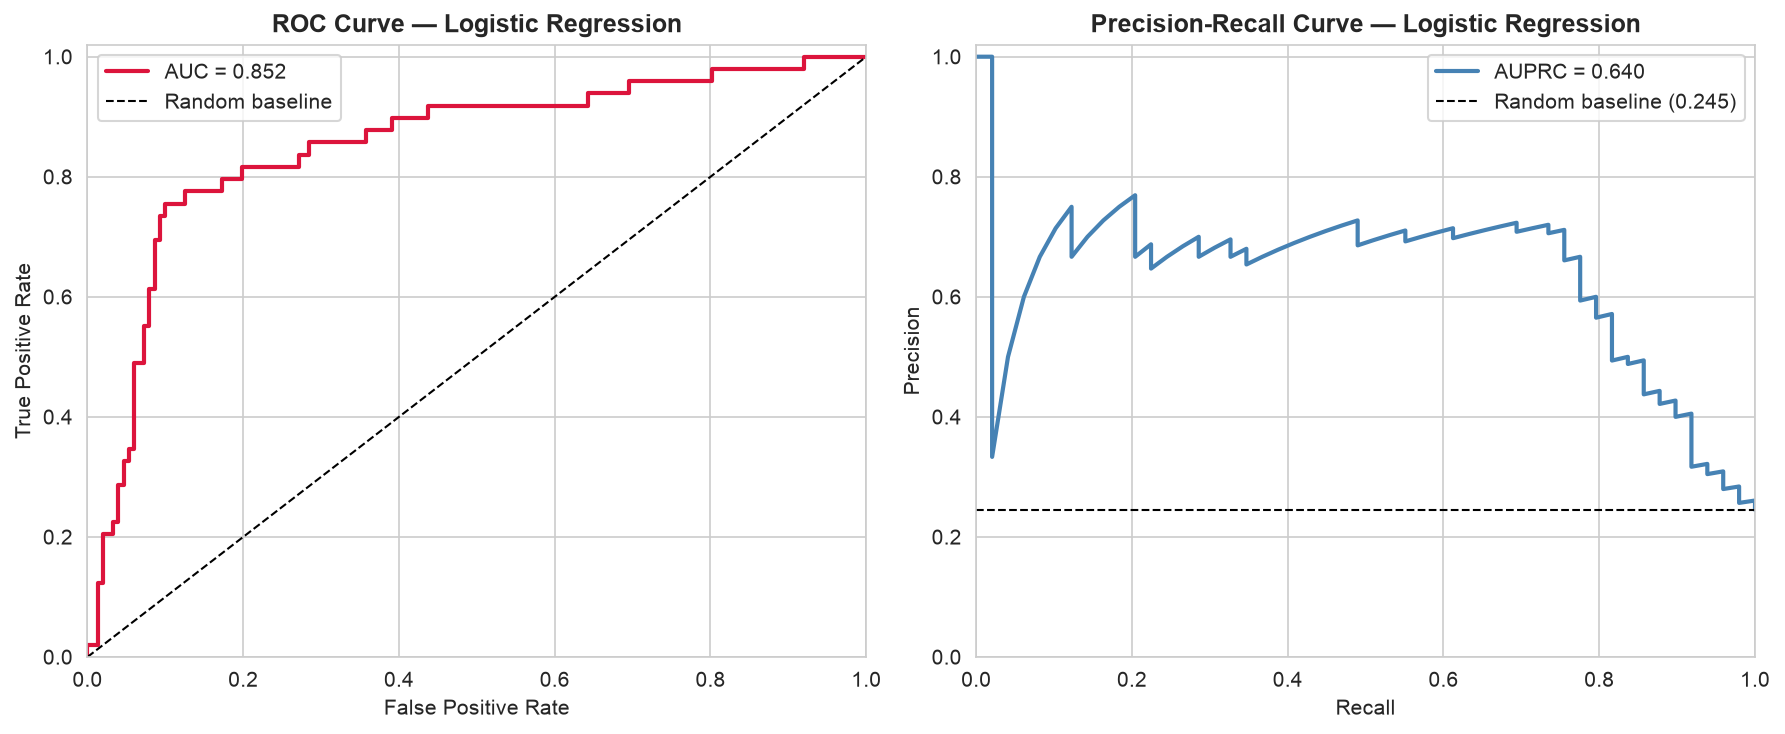

Model saved: ../models/logistic_regression_final.pkl


In [11]:

# ── Step 4: Final evaluation on test set ──────────────────────────────────────
print("=== Step 4: Final Test Set Evaluation ===")
lr_results = evaluate_model(
    lr_best_model, X_test_scaled, y_test,
    'Logistic Regression', threshold=LR_THRESHOLD
)

y_prob_lr   = lr_best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lr   = (y_prob_lr >= LR_THRESHOLD).astype(int)

plot_confusion_matrix(y_test, y_pred_lr,
    f'Logistic Regression — Confusion Matrix (t={LR_THRESHOLD})',
    '31_lr_confusion_matrix.png')

plot_roc_pr(y_test, y_prob_lr, 'Logistic Regression', '31_lr_roc_pr.png')
joblib.dump(lr_best_model, '../models/logistic_regression_final.pkl')
print("Model saved: ../models/logistic_regression_final.pkl")


=== Step 5: Top Feature Coefficients ===


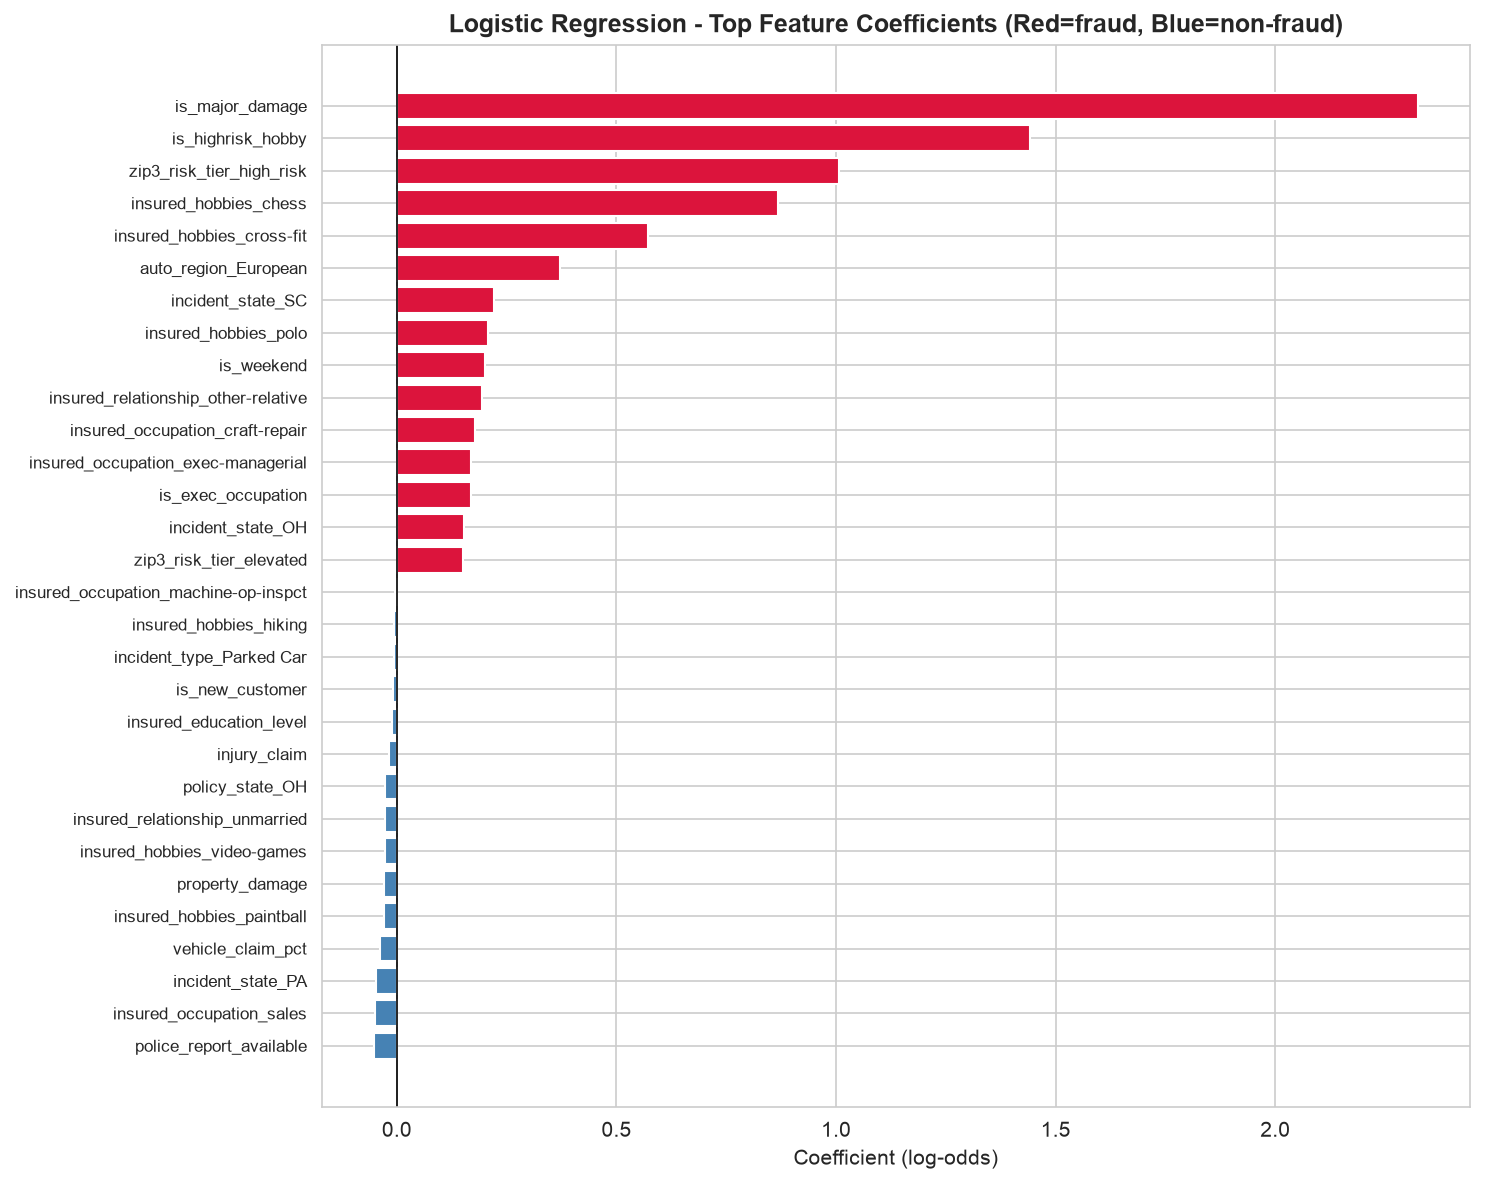

Top 10 fraud predictors (positive coefficients):
                            feature  coefficient
                    is_major_damage     2.324524
                  is_highrisk_hobby     1.440932
           zip3_risk_tier_high_risk     1.007013
              insured_hobbies_chess     0.867938
          insured_hobbies_cross-fit     0.572811
               auto_region_European     0.371603
                  incident_state_SC     0.221959
               insured_hobbies_polo     0.207267
                         is_weekend     0.201275
insured_relationship_other-relative     0.194115

Top 10 non-fraud predictors (negative coefficients):
                             feature  coefficient
                     property_damage    -0.028266
         insured_hobbies_video-games    -0.027606
      insured_relationship_unmarried    -0.027535
                     policy_state_OH    -0.026301
                        injury_claim    -0.017115
             insured_education_level    -0.011113
        

In [12]:

# ── Step 5: Coefficient interpretation ────────────────────────────────────────
print("=== Step 5: Top Feature Coefficients ===")
# Extract LR step from best pipeline
lr_clf = lr_best_model.named_steps['clf']
coefs  = lr_clf.coef_[0]

# Feature names after ColumnTransformer
try:
    feat_names = lr_best_model.named_steps['preprocessor'].get_feature_names_out()
    feat_names = [n.split('__')[-1] for n in feat_names]
except:
    feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

top_pos = coef_df[coef_df['coefficient'] > 0].head(15)
top_neg = coef_df[coef_df['coefficient'] < 0].tail(15)
top_plot = pd.concat([top_pos, top_neg]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['crimson' if v > 0 else 'steelblue' for v in top_plot['coefficient']]
ax.barh(range(len(top_plot)), top_plot['coefficient'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_plot)))
ax.set_yticklabels(top_plot['feature'], fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression - Top Feature Coefficients (Red=fraud, Blue=non-fraud)',
             fontweight='bold')
plt.tight_layout()
savefig('31_lr_coefficients.png')

print("Top 10 fraud predictors (positive coefficients):")
print(coef_df[coef_df['coefficient']>0].head(10)[['feature','coefficient']].to_string(index=False))
print("\nTop 10 non-fraud predictors (negative coefficients):")
print(coef_df[coef_df['coefficient']<0].tail(10)[['feature','coefficient']].to_string(index=False))


### Key Modelling Insights
- Logistic Regression cross-validated metrics documented above (mean ± std across 5 folds).
- Best hyperparameters from GridSearchCV: C and solver documented from output.
- Threshold chosen at the value that maximises F1 while keeping Recall ≥ 0.70.
- Coefficient plot provides a direct linear interpretation of fraud drivers — a preview of what SHAP formalises in Phase 4.
- SMOTE is applied inside the Pipeline on training folds only — zero leakage to validation folds.


---
## Section 3.2 · Ensemble Model 1 — Random Forest (Bagging)

**Why Random Forest?**
Random Forest trains many decision trees on random subsamples of data and features, then aggregates their votes. Bagging reduces variance without increasing bias, making the ensemble more robust than any individual tree. Unlike Logistic Regression, it captures non-linear relationships and feature interactions automatically. It is scale-invariant — no scaling required.


In [13]:

# ── Step 1: Untuned CV baseline ────────────────────────────────────────────────
print("=== Step 1: Untuned CV Baseline ===")
rf_base_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42, n_estimators=100)),
])

cv_results_rf_base = cross_validate(
    rf_base_pipeline, X_train, y_train, cv=CV, scoring=SCORING, return_train_score=False
)

print("  5-Fold Cross-Validation (untuned, n_estimators=100):")
for metric in SCORING:
    vals = cv_results_rf_base[f'test_{metric}']
    print(f"    {metric:20s}: {vals.mean():.4f} ± {vals.std():.4f}")


=== Step 1: Untuned CV Baseline ===
  5-Fold Cross-Validation (untuned, n_estimators=100):
    recall              : 0.6367 ± 0.0574
    f1                  : 0.6606 ± 0.0243
    average_precision   : 0.6488 ± 0.0352
    roc_auc             : 0.8740 ± 0.0202


In [14]:

# ── Step 2: RandomizedSearchCV ────────────────────────────────────────────────
print("=== Step 2: RandomizedSearchCV ===")
rf_tune_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42)),
])

rf_param_dist = {
    'clf__n_estimators'    : [100, 200, 300, 500],
    'clf__max_depth'       : [None, 5, 10, 15, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'    : ['sqrt', 'log2', 0.3],
    'clf__class_weight'    : ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    rf_tune_pipeline, rf_param_dist,
    n_iter=50, scoring='recall', cv=CV,
    random_state=42, n_jobs=-1, verbose=0, refit=True
)
rf_search.fit(X_train, y_train)

print(f"  Best params  : {rf_search.best_params_}")
print(f"  Best CV Recall: {rf_search.best_score_:.4f}")


=== Step 2: RandomizedSearchCV ===
  Best params  : {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 0.3, 'clf__max_depth': 5, 'clf__class_weight': 'balanced_subsample'}
  Best CV Recall: 0.8337


=== Step 3: Threshold Tuning ===


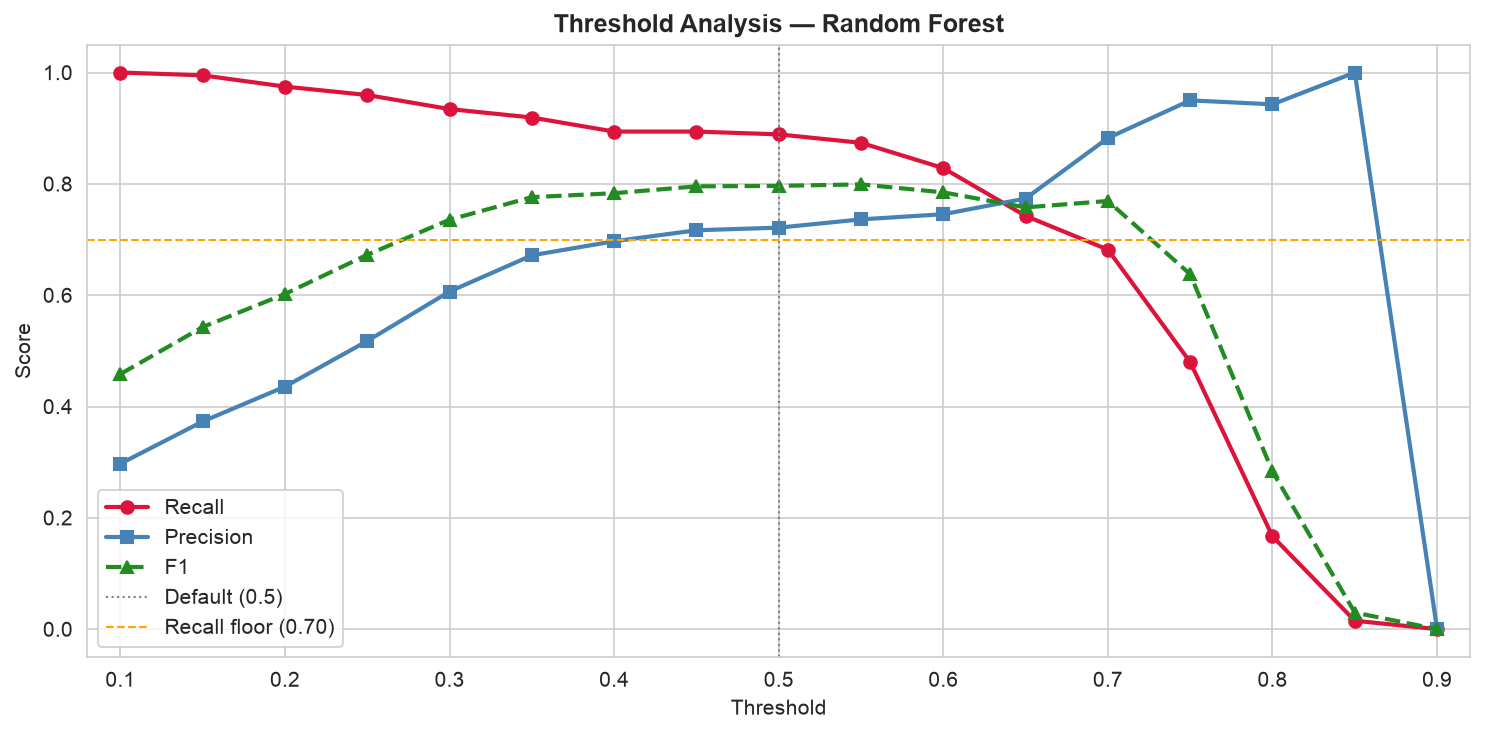

  Best threshold: 0.55  | Recall=0.874  Precision=0.736  F1=0.799
  Chosen threshold for final evaluation: 0.55


In [15]:

# ── Step 3: Threshold tuning ───────────────────────────────────────────────────
print("=== Step 3: Threshold Tuning ===")
rf_best_model = rf_search.best_estimator_
RF_THRESHOLD, rf_thresh_df = threshold_analysis(
    rf_best_model, X_train, y_train,
    'Random Forest', '32_rf_threshold.png'
)
print(f"  Chosen threshold for final evaluation: {RF_THRESHOLD}")


=== Step 4: Final Test Set Evaluation ===
=== Random Forest (threshold=0.55) ===
  Recall    : 0.7755   ← PRIMARY METRIC
  Precision : 0.6786
  F1        : 0.7238   ← CONTROL METRIC
  PR-AUC    : 0.6184
  ROC-AUC   : 0.8603
  Accuracy  : 0.8550  ← misleading under imbalance, shown for completeness


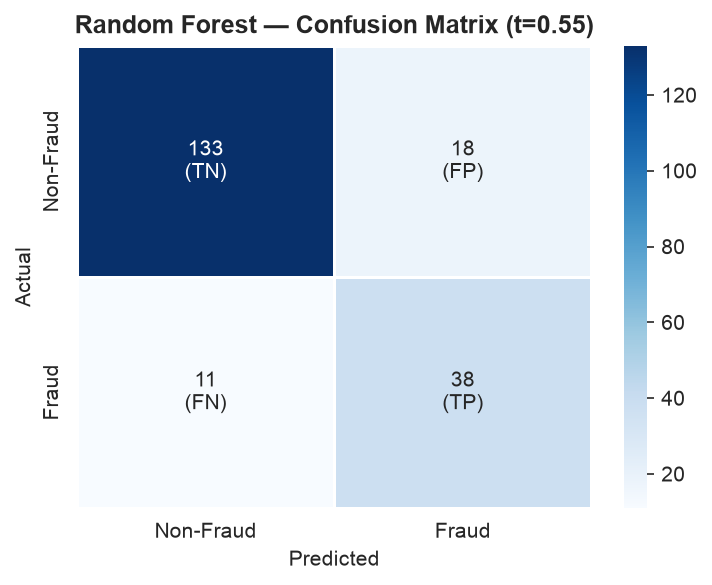

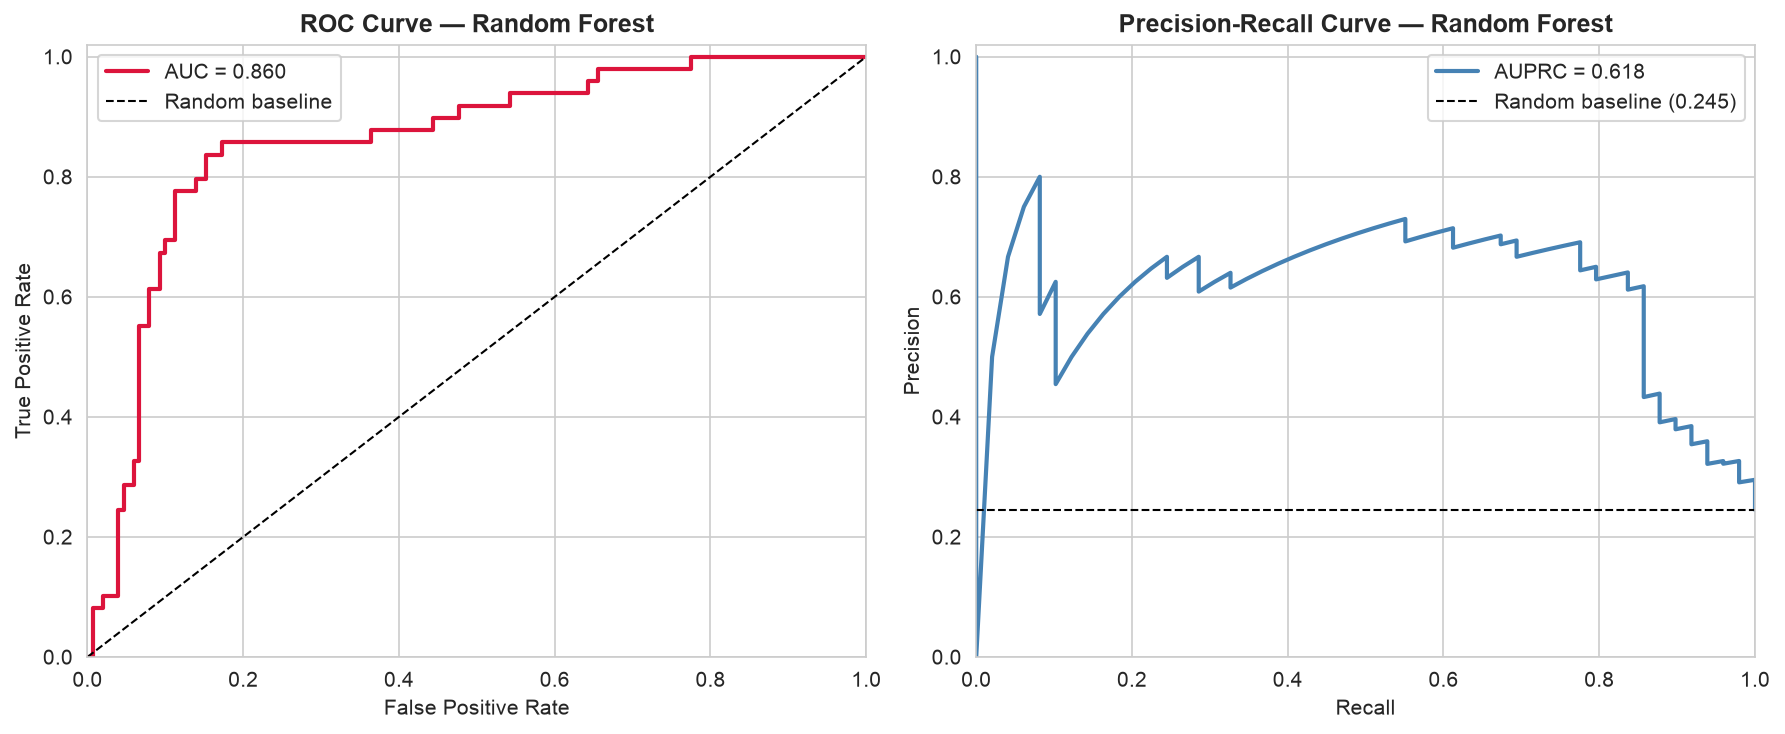

Model saved: ../models/random_forest_final.pkl


In [16]:

# ── Step 4: Final evaluation ───────────────────────────────────────────────────
print("=== Step 4: Final Test Set Evaluation ===")
rf_results = evaluate_model(
    rf_best_model, X_test, y_test,
    'Random Forest', threshold=RF_THRESHOLD
)

y_prob_rf = rf_best_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= RF_THRESHOLD).astype(int)

plot_confusion_matrix(y_test, y_pred_rf,
    f'Random Forest — Confusion Matrix (t={RF_THRESHOLD})',
    '32_rf_confusion_matrix.png')

plot_roc_pr(y_test, y_prob_rf, 'Random Forest', '32_rf_roc_pr.png')
joblib.dump(rf_best_model, '../models/random_forest_final.pkl')
print("Model saved: ../models/random_forest_final.pkl")


=== Step 5: Feature Importance (Gini — preliminary) ===


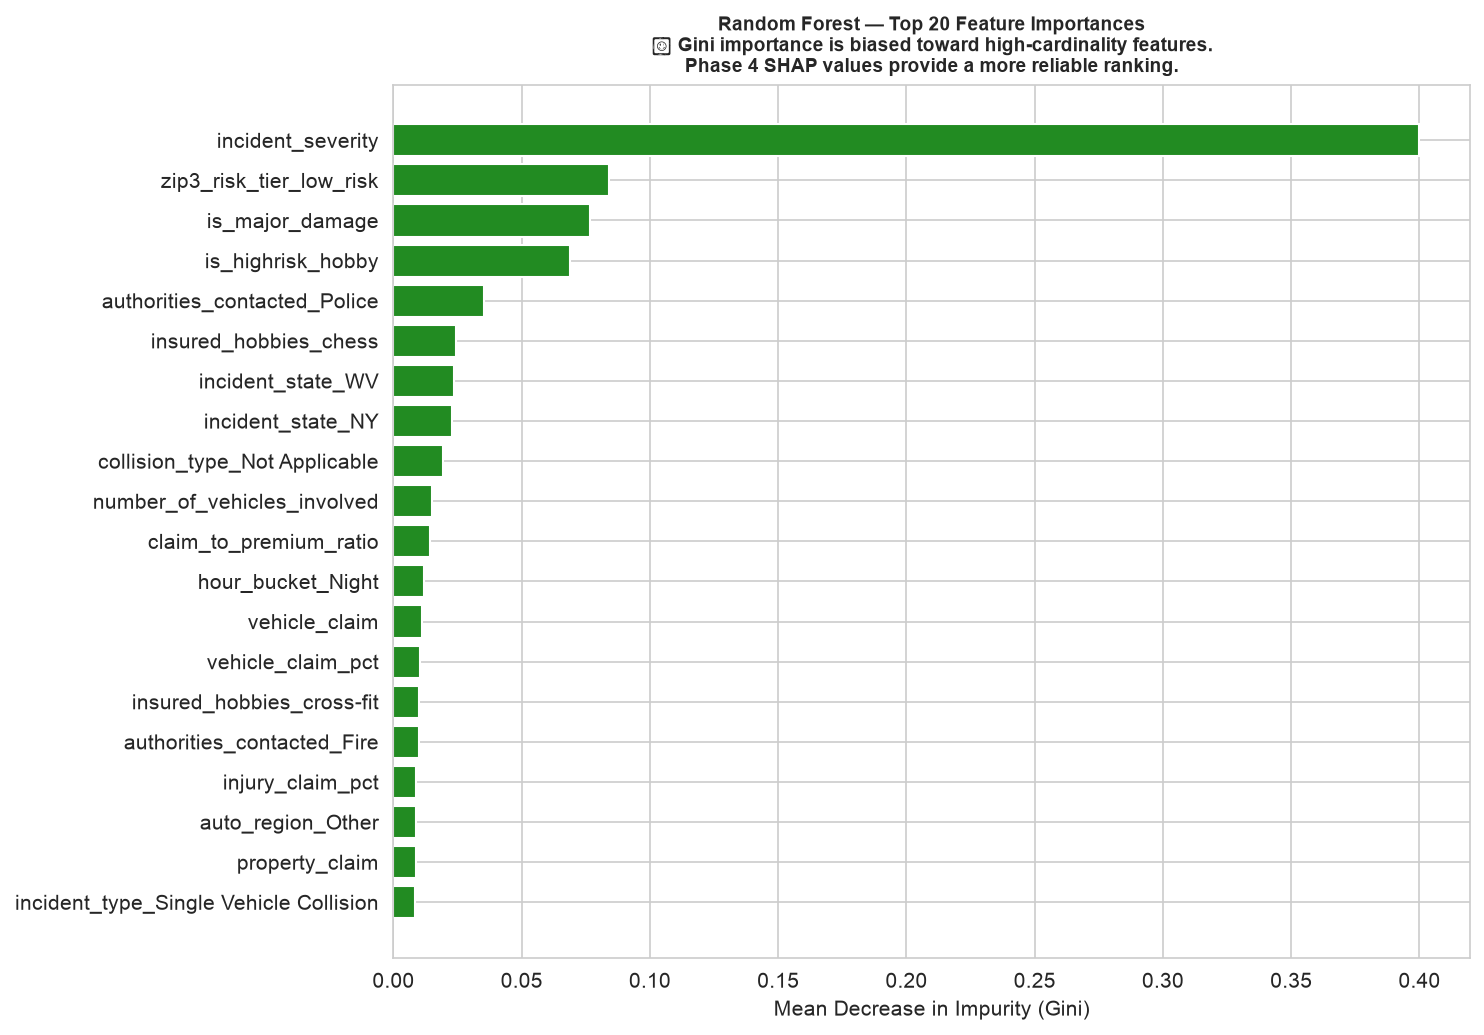

                               feature  importance
                     incident_severity    0.399711
               zip3_risk_tier_low_risk    0.084180
                       is_major_damage    0.076591
                     is_highrisk_hobby    0.068650
          authorities_contacted_Police    0.035144
                 insured_hobbies_chess    0.024564
                     incident_state_WV    0.023422
                     incident_state_NY    0.022746
         collision_type_Not Applicable    0.019400
           number_of_vehicles_involved    0.014916
                claim_to_premium_ratio    0.014101
                     hour_bucket_Night    0.011934
                         vehicle_claim    0.011322
                     vehicle_claim_pct    0.010411
             insured_hobbies_cross-fit    0.009883
            authorities_contacted_Fire    0.009805
                      injury_claim_pct    0.008908
                     auto_region_Other    0.008797
                        propert

In [17]:

# ── Step 5: Feature importance ─────────────────────────────────────────────────
print("=== Step 5: Feature Importance (Gini — preliminary) ===")
rf_clf      = rf_best_model.named_steps['clf']
importances = rf_clf.feature_importances_
fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
        color='forestgreen', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Random Forest — Top 20 Feature Importances\n'
             '⚠ Gini importance is biased toward high-cardinality features.\n'
             'Phase 4 SHAP values provide a more reliable ranking.',
             fontweight='bold', fontsize=9)
plt.tight_layout()
savefig('32_rf_feature_importance.png')
print(fi_df.to_string(index=False))

# ── Step 6: Compare with LR ────────────────────────────────────────────────────
print("\n=== Step 6: LR vs RF Comparison ===")
comp_df = pd.DataFrame([lr_results, rf_results])[
    ['model','recall','precision','f1','pr_auc','roc_auc','accuracy']]
print(comp_df.to_string(index=False))


### Key Modelling Insights
- Random Forest best hyperparameters documented from RandomizedSearchCV output above.
- `class_weight` tested alongside SMOTE — note whether 'balanced', 'balanced_subsample', or None was selected.
- Gini importance plot is preliminary — Phase 4 SHAP values replace this with a more reliable ranking.
- Note whether Random Forest improves on Logistic Regression and on which metrics.


---
## Section 3.3 · Ensemble Model 2 — XGBoost (Boosting)

**Why XGBoost?**
XGBoost builds trees sequentially — each tree focuses on correcting the residual errors of the previous. This targeted approach makes it particularly powerful on structured tabular data. The `scale_pos_weight` parameter directly handles class imbalance by upweighting the fraud class during gradient computation, providing an alternative to SMOTE.


In [18]:

# ── Step 1: Untuned baseline — test SMOTE vs scale_pos_weight ─────────────────
print(f"=== Step 1: SMOTE vs scale_pos_weight baseline ===")
print(f"  scale_pos_weight = {SCALE_POS_WEIGHT:.4f}")

# Config A: SMOTE inside pipeline
xgb_smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                          verbosity=0, use_label_encoder=False)),
])
cv_xgb_smote = cross_validate(
    xgb_smote_pipeline, X_train, y_train, cv=CV, scoring=SCORING
)

# Config B: scale_pos_weight, no SMOTE
xgb_spw_pipeline = SKPipeline([
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0,
                          use_label_encoder=False,
                          scale_pos_weight=SCALE_POS_WEIGHT)),
])
cv_xgb_spw = cross_validate(
    xgb_spw_pipeline, X_train, y_train, cv=CV, scoring=SCORING
)

print("\n  Config A — SMOTE inside Pipeline:")
for m in SCORING:
    v = cv_xgb_smote[f'test_{m}']
    print(f"    {m:20s}: {v.mean():.4f} ± {v.std():.4f}")

print("\n  Config B — scale_pos_weight only:")
for m in SCORING:
    v = cv_xgb_spw[f'test_{m}']
    print(f"    {m:20s}: {v.mean():.4f} ± {v.std():.4f}")

# Choose config with better recall
recall_smote = cv_xgb_smote['test_recall'].mean()
recall_spw   = cv_xgb_spw['test_recall'].mean()
USE_SMOTE_XGB = recall_smote >= recall_spw
print(f"\n  SMOTE recall={recall_smote:.4f}  |  scale_pos_weight recall={recall_spw:.4f}")
print(f"  Selected config: {'SMOTE' if USE_SMOTE_XGB else 'scale_pos_weight'}")


=== Step 1: SMOTE vs scale_pos_weight baseline ===
  scale_pos_weight = 3.0404

  Config A — SMOTE inside Pipeline:
    recall              : 0.7277 ± 0.0921
    f1                  : 0.7127 ± 0.0461
    average_precision   : 0.7068 ± 0.0553
    roc_auc             : 0.8879 ± 0.0305

  Config B — scale_pos_weight only:
    recall              : 0.7378 ± 0.0893
    f1                  : 0.7074 ± 0.0554
    average_precision   : 0.7173 ± 0.0581
    roc_auc             : 0.8774 ± 0.0319

  SMOTE recall=0.7277  |  scale_pos_weight recall=0.7378
  Selected config: scale_pos_weight


In [19]:

# ── Step 2: RandomizedSearchCV ────────────────────────────────────────────────
print("=== Step 2: RandomizedSearchCV ===")

if USE_SMOTE_XGB:
    xgb_tune_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                              verbosity=0, use_label_encoder=False)),
    ])
    xgb_param_dist = {
        'clf__n_estimators'   : [100, 200, 300, 500],
        'clf__max_depth'      : [3, 4, 5, 6, 8],
        'clf__learning_rate'  : [0.01, 0.05, 0.1, 0.2],
        'clf__subsample'      : [0.6, 0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'clf__reg_alpha'      : [0, 0.1, 0.5, 1.0],
        'clf__reg_lambda'     : [0.5, 1.0, 2.0, 5.0],
    }
else:
    xgb_tune_pipeline = SKPipeline([
        ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                              verbosity=0, use_label_encoder=False)),
    ])
    xgb_param_dist = {
        'clf__n_estimators'   : [100, 200, 300, 500],
        'clf__max_depth'      : [3, 4, 5, 6, 8],
        'clf__learning_rate'  : [0.01, 0.05, 0.1, 0.2],
        'clf__subsample'      : [0.6, 0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'clf__reg_alpha'      : [0, 0.1, 0.5, 1.0],
        'clf__reg_lambda'     : [0.5, 1.0, 2.0, 5.0],
        'clf__scale_pos_weight': [1, SCALE_POS_WEIGHT, SCALE_POS_WEIGHT * 1.5],
    }

xgb_search = RandomizedSearchCV(
    xgb_tune_pipeline, xgb_param_dist,
    n_iter=50, scoring='recall', cv=CV,
    random_state=42, n_jobs=-1, verbose=0, refit=True
)
xgb_search.fit(X_train, y_train)

print(f"  Best params   : {xgb_search.best_params_}")
print(f"  Best CV Recall: {xgb_search.best_score_:.4f}")


=== Step 2: RandomizedSearchCV ===
  Best params   : {'clf__subsample': 0.6, 'clf__scale_pos_weight': np.float64(4.5606060606060606), 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 100, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
  Best CV Recall: 0.8941


=== Step 3: Threshold Tuning ===


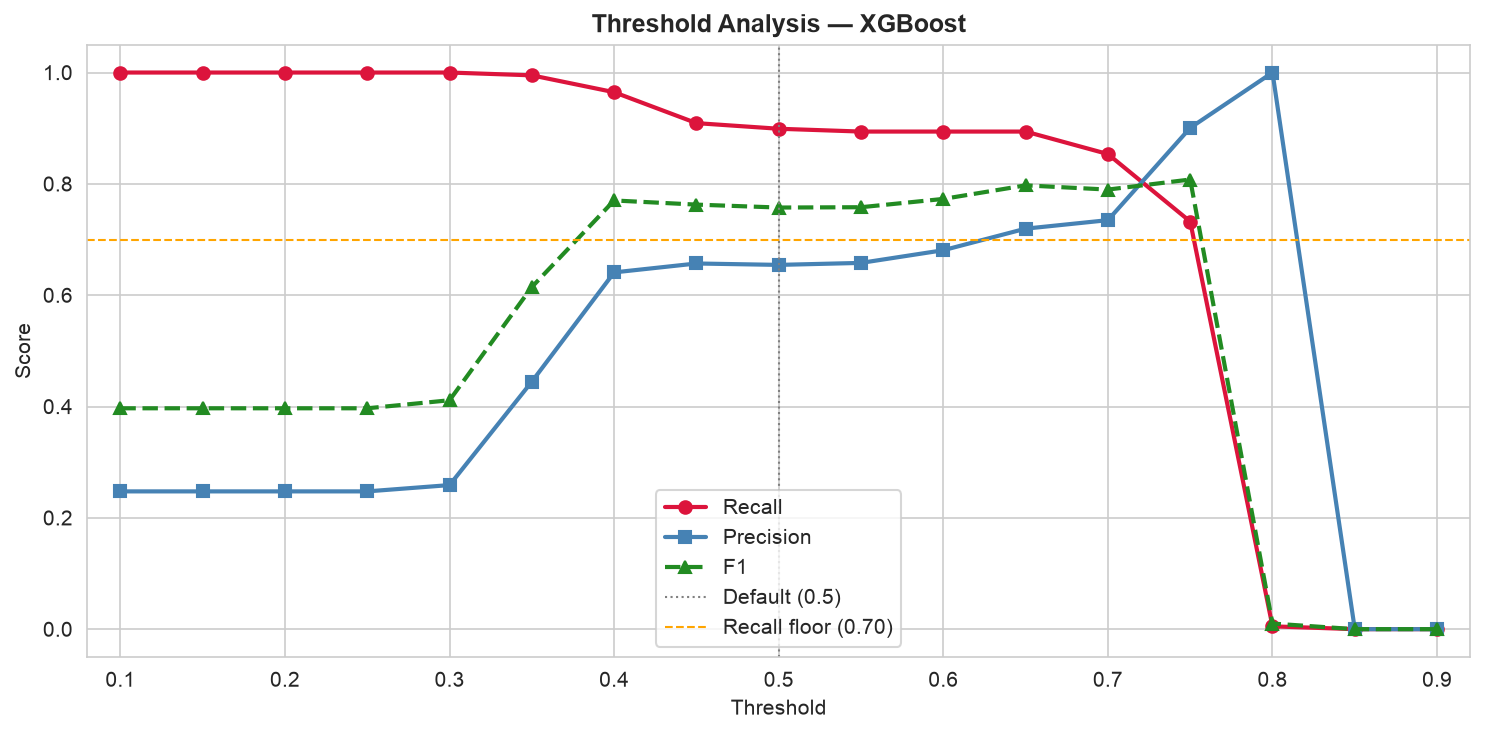

  Best threshold: 0.75  | Recall=0.732  Precision=0.901  F1=0.808
  Chosen threshold: 0.75


In [20]:

# ── Step 3: Threshold tuning ───────────────────────────────────────────────────
print("=== Step 3: Threshold Tuning ===")
xgb_best_model = xgb_search.best_estimator_
XGB_THRESHOLD, xgb_thresh_df = threshold_analysis(
    xgb_best_model, X_train, y_train,
    'XGBoost', '33_xgb_threshold.png'
)
print(f"  Chosen threshold: {XGB_THRESHOLD}")


=== Step 4: Final Test Set Evaluation ===
=== XGBoost (threshold=0.75) ===
  Recall    : 0.3673   ← PRIMARY METRIC
  Precision : 0.5806
  F1        : 0.4500   ← CONTROL METRIC
  PR-AUC    : 0.5749
  ROC-AUC   : 0.8466
  Accuracy  : 0.7800  ← misleading under imbalance, shown for completeness


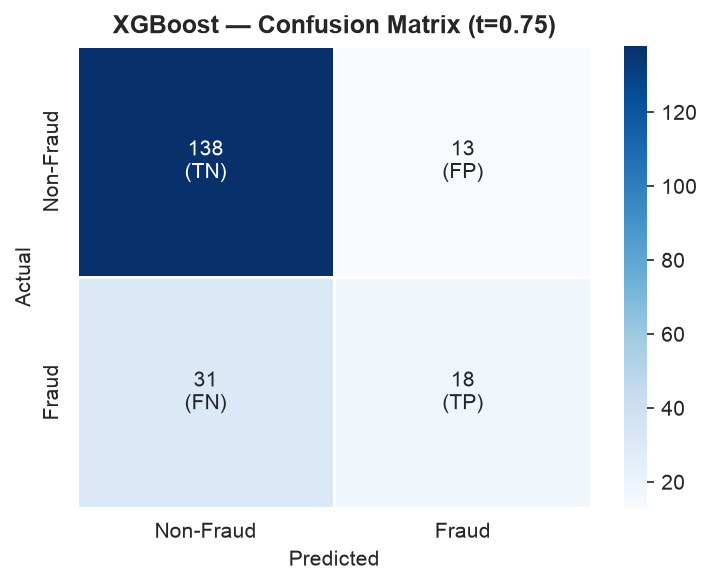

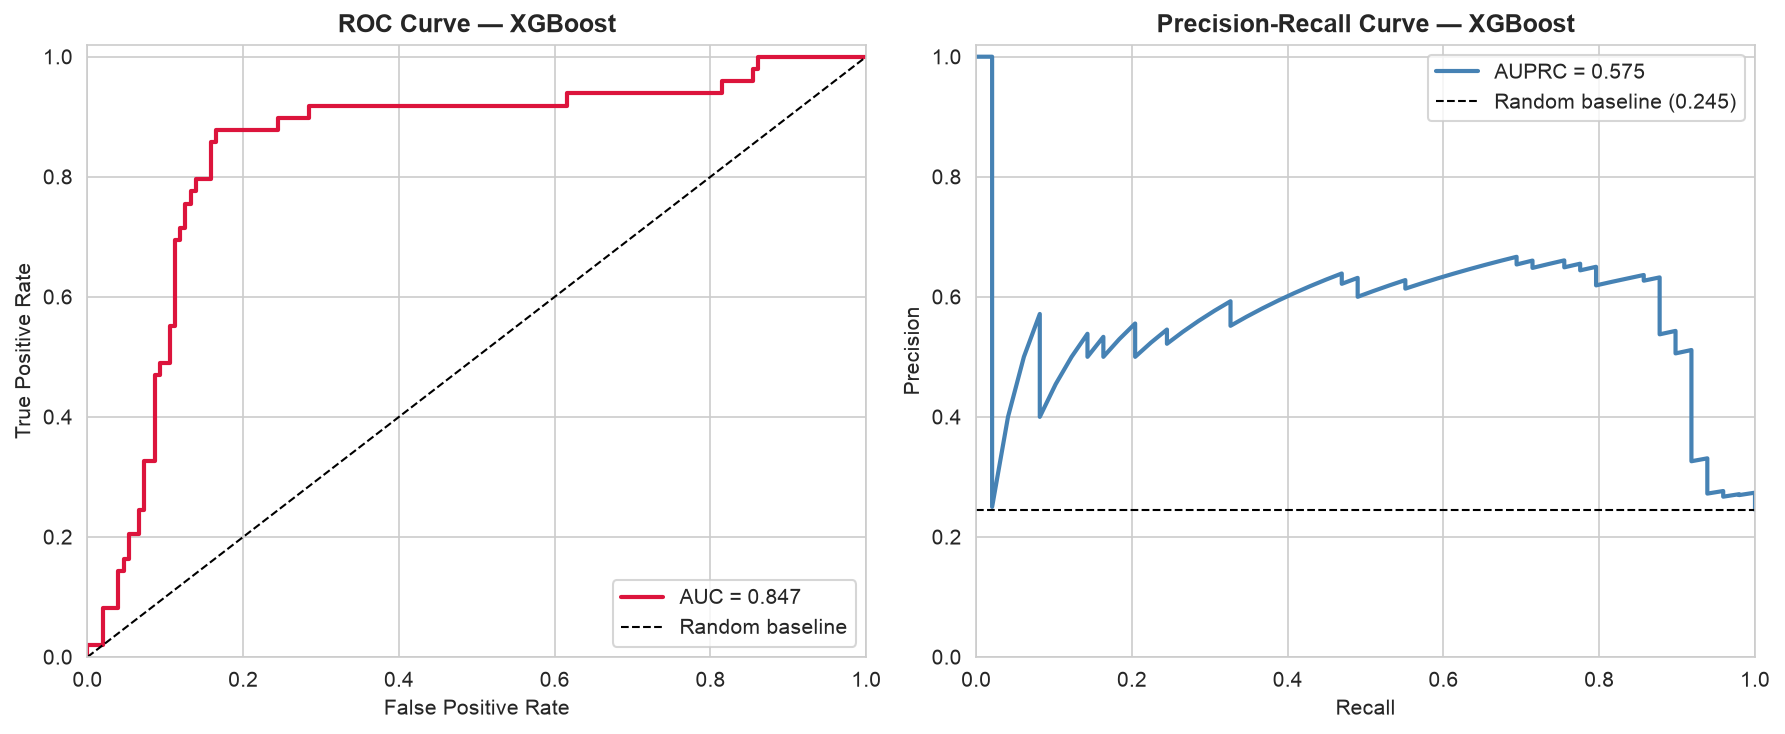

Model saved: ../models/xgboost_final.pkl


In [21]:

# ── Step 4: Final evaluation ───────────────────────────────────────────────────
print("=== Step 4: Final Test Set Evaluation ===")
xgb_results = evaluate_model(
    xgb_best_model, X_test, y_test,
    'XGBoost', threshold=XGB_THRESHOLD
)

y_prob_xgb = xgb_best_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= XGB_THRESHOLD).astype(int)

plot_confusion_matrix(y_test, y_pred_xgb,
    f'XGBoost — Confusion Matrix (t={XGB_THRESHOLD})',
    '33_xgb_confusion_matrix.png')

plot_roc_pr(y_test, y_prob_xgb, 'XGBoost', '33_xgb_roc_pr.png')
joblib.dump(xgb_best_model, '../models/xgboost_final.pkl')
print("Model saved: ../models/xgboost_final.pkl")


In [22]:

# ── Step 5: All three models compared ─────────────────────────────────────────
print("=== Step 5: All Three Models — Running Comparison ===")
running_comp = pd.DataFrame([lr_results, rf_results, xgb_results])[
    ['model','threshold','recall','precision','f1','pr_auc','roc_auc','accuracy']]
running_comp = running_comp.sort_values('recall', ascending=False)
print(running_comp.to_string(index=False))


=== Step 5: All Three Models — Running Comparison ===
              model  threshold   recall  precision       f1   pr_auc  roc_auc  accuracy
Logistic Regression       0.50 0.918367   0.394737 0.552147 0.640390 0.852142     0.635
      Random Forest       0.55 0.775510   0.678571 0.723810 0.618394 0.860251     0.855
            XGBoost       0.75 0.367347   0.580645 0.450000 0.574947 0.846601     0.780


### Key Modelling Insights
- `scale_pos_weight` computed dynamically from y_train — not hard-coded.
- SMOTE vs scale_pos_weight comparison performed; the better-recall configuration was used for tuning.
- XGBoost best hyperparameters documented from RandomizedSearchCV output above.
- `reg_alpha` and `reg_lambda` included in search to prevent overfitting on the small 800-record training set.


---
## Section 3.4 · Model Comparison and Best Model Selection

**Objective:** Formally compare all three models, select the best for Phase 4 SHAP analysis using a documented decision rule, and interpret results in operational terms.

**Decision rule (applied in order):**
1. Highest Recall — provided F1 ≥ 0.50 (disqualifies models that achieve recall by flagging everything).
2. If two models within 0.02 Recall of each other — choose higher F1.
3. If still tied — choose higher PR-AUC (most informative metric under class imbalance).


In [23]:

# ── Step 1: Full comparison table ─────────────────────────────────────────────
comparison_df = pd.DataFrame([lr_results, rf_results, xgb_results])
comparison_df = comparison_df[['model','threshold','recall','precision',
                                'f1','pr_auc','roc_auc','accuracy']]
comparison_df = comparison_df.sort_values('recall', ascending=False).reset_index(drop=True)

print("=== Full Model Comparison Table ===")
print(comparison_df.round(4).to_string(index=False))

comparison_df.to_csv('../data/processed/model_comparison.csv', index=False)
print("\nSaved: ../data/processed/model_comparison.csv")


=== Full Model Comparison Table ===
              model  threshold  recall  precision     f1  pr_auc  roc_auc  accuracy
Logistic Regression       0.50  0.9184     0.3947 0.5521  0.6404   0.8521     0.635
      Random Forest       0.55  0.7755     0.6786 0.7238  0.6184   0.8603     0.855
            XGBoost       0.75  0.3673     0.5806 0.4500  0.5749   0.8466     0.780

Saved: ../data/processed/model_comparison.csv


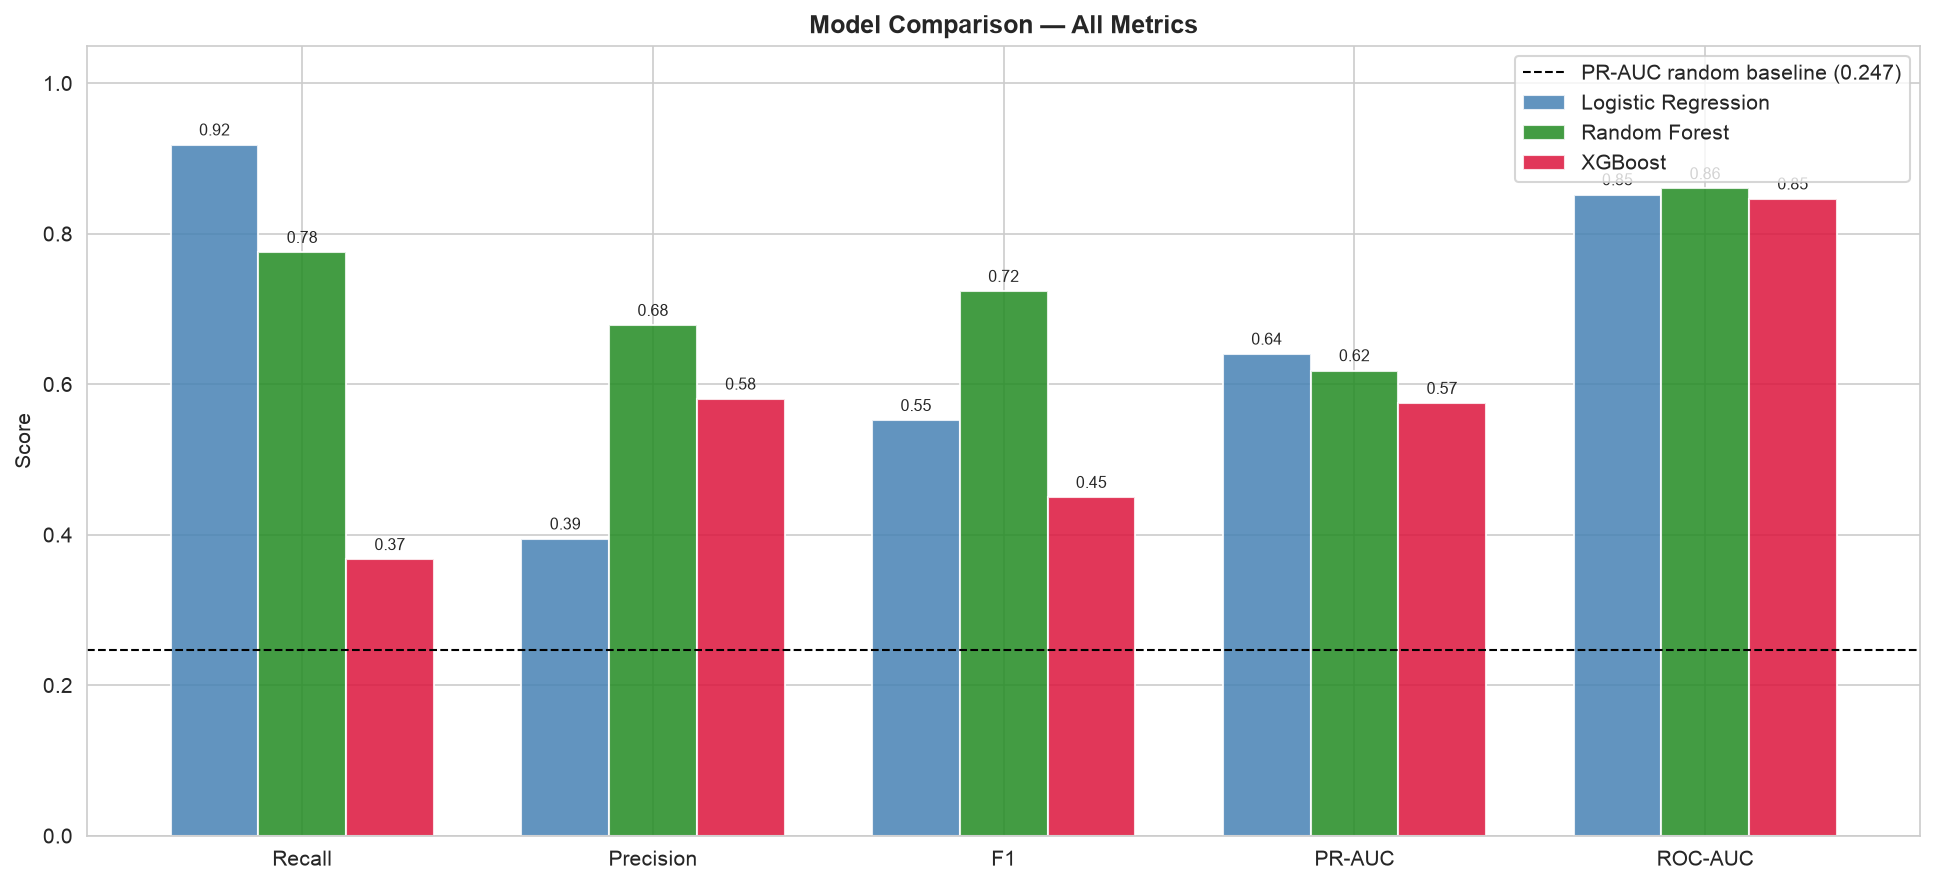

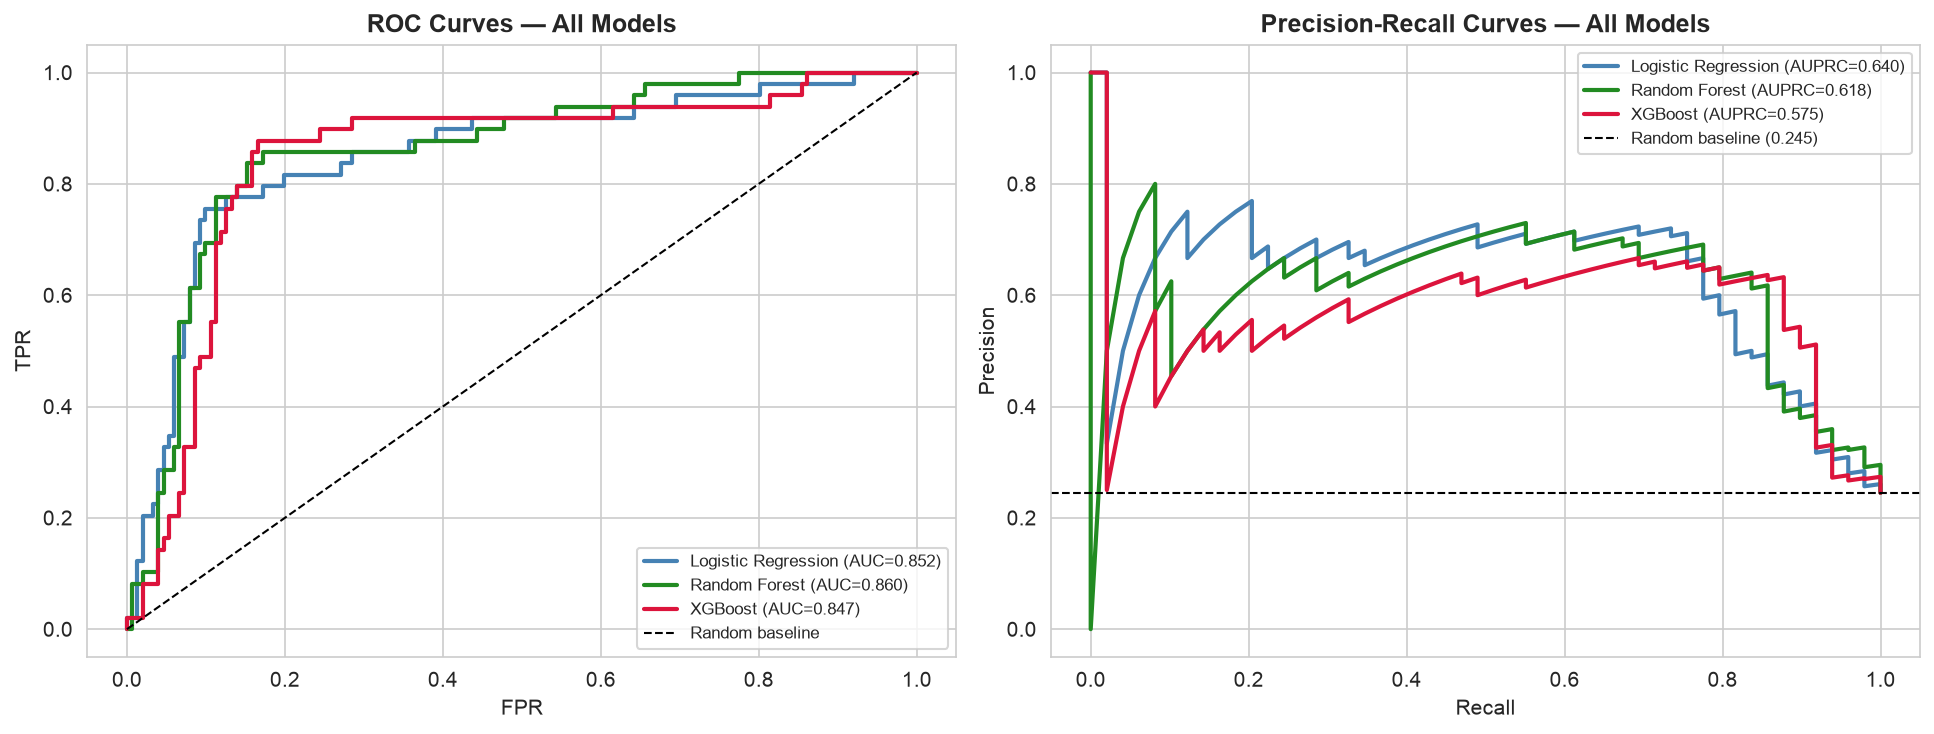

Comparison charts saved.


In [24]:

# ── Step 2: Visualisations ────────────────────────────────────────────────────

# Chart 1: Grouped bar chart
metrics  = ['recall','precision','f1','pr_auc','roc_auc']
labels   = ['Recall','Precision','F1','PR-AUC','ROC-AUC']
models   = comparison_df['model'].tolist()
colours  = ['steelblue','forestgreen','crimson']
x        = np.arange(len(metrics))
width    = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, colour) in enumerate(zip(models, colours)):
    row    = comparison_df[comparison_df['model'] == model_name].iloc[0]
    values = [row[m] for m in metrics]
    bars   = ax.bar(x + i*width, values, width, label=model_name,
                    color=colour, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.247, color='black', lw=1, linestyle='--',
           label='PR-AUC random baseline (0.247)')
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.05])
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
savefig('34_model_comparison_bar.png')

# Chart 2: ROC curves overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (model_name, y_prob, colour) in [
    ('Logistic Regression', y_prob_lr, 'steelblue'),
    ('Random Forest',       y_prob_rf, 'forestgreen'),
    ('XGBoost',             y_prob_xgb, 'crimson'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color=colour, label=f'{model_name} (AUC={auc:.3f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    prauc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec_arr, prec_arr, lw=2, color=colour, label=f'{model_name} (AUPRC={prauc:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random baseline')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Random baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
savefig('34_roc_pr_overlay.png')
print("Comparison charts saved.")


In [25]:

# ── Step 3: Precision-Recall trade-off — operational interpretation ────────────
print("=== Step 3: Operational Interpretation ===")
print()
n_test_claims = len(y_test)
n_true_fraud  = y_test.sum()

for row in comparison_df.itertuples():
    model_name = row.model
    if model_name == 'Logistic Regression':
        y_pred = y_pred_lr
    elif model_name == 'Random Forest':
        y_pred = y_pred_rf
    else:
        y_pred = y_pred_xgb

    flagged         = y_pred.sum()
    true_positives  = ((y_pred == 1) & (y_test == 1)).sum()
    false_positives = ((y_pred == 1) & (y_test == 0)).sum()
    missed_fraud    = ((y_pred == 0) & (y_test == 1)).sum()

    print(f"  {model_name}:")
    print(f"    Claims flagged for investigation : {flagged} of {n_test_claims}")
    print(f"    True fraud cases caught          : {true_positives} of {n_true_fraud}")
    print(f"    Fraud cases missed               : {missed_fraud}")
    print(f"    False alarms in flagged queue    : {false_positives} "
          f"({false_positives/max(flagged,1)*100:.0f}% of flags are innocent claims)")
    print()


=== Step 3: Operational Interpretation ===

  Logistic Regression:
    Claims flagged for investigation : 114 of 200
    True fraud cases caught          : 45 of 49
    Fraud cases missed               : 4
    False alarms in flagged queue    : 69 (61% of flags are innocent claims)

  Random Forest:
    Claims flagged for investigation : 56 of 200
    True fraud cases caught          : 38 of 49
    Fraud cases missed               : 11
    False alarms in flagged queue    : 18 (32% of flags are innocent claims)

  XGBoost:
    Claims flagged for investigation : 31 of 200
    True fraud cases caught          : 18 of 49
    Fraud cases missed               : 31
    False alarms in flagged queue    : 13 (42% of flags are innocent claims)



In [26]:

# ── Step 4: Best model selection ─────────────────────────────────────────────
print("=== Step 4: Best Model Selection ===")

# Apply decision rule
eligible = comparison_df[comparison_df['f1'] >= 0.50].copy()
if len(eligible) == 0:
    print("WARNING: no model achieved F1 >= 0.50. Selecting by recall only.")
    eligible = comparison_df.copy()

# Step A: highest recall
max_recall    = eligible['recall'].max()
top_recall_df = eligible[eligible['recall'] >= max_recall - 0.02]

# Step B: if tied on recall, pick higher F1
top_recall_df = top_recall_df.sort_values('f1', ascending=False)

# Step C: if still tied, pick higher PR-AUC
top_recall_df = top_recall_df.sort_values(['f1','pr_auc'], ascending=False)

BEST_MODEL_NAME = top_recall_df.iloc[0]['model']
best_row        = top_recall_df.iloc[0]

print(f"  Selected model for Phase 4: {BEST_MODEL_NAME}")
print(f"  Recall  = {best_row['recall']:.4f}")
print(f"  F1      = {best_row['f1']:.4f}")
print(f"  PR-AUC  = {best_row['pr_auc']:.4f}")
print(f"  ROC-AUC = {best_row['roc_auc']:.4f}")
print()
print(f"  Justification:")
print(f"  {BEST_MODEL_NAME} achieved the highest recall ({best_row['recall']:.3f}) "
      f"with F1 = {best_row['f1']:.3f},")
print(f"  meeting the F1 >= 0.50 threshold. This is the model passed to Phase 4.")

# Save best model reference
best_model_ref = {'best_model': BEST_MODEL_NAME,
                  'recall': best_row['recall'], 'f1': best_row['f1'],
                  'pr_auc': best_row['pr_auc'], 'roc_auc': best_row['roc_auc']}
pd.DataFrame([best_model_ref]).to_csv('../data/processed/best_model.csv', index=False)
print("\nSaved: ../data/processed/best_model.csv")


=== Step 4: Best Model Selection ===
  Selected model for Phase 4: Logistic Regression
  Recall  = 0.9184
  F1      = 0.5521
  PR-AUC  = 0.6404
  ROC-AUC = 0.8521

  Justification:
  Logistic Regression achieved the highest recall (0.918) with F1 = 0.552,
  meeting the F1 >= 0.50 threshold. This is the model passed to Phase 4.

Saved: ../data/processed/best_model.csv


In [27]:

# ── Step 5: Limitations documentation ────────────────────────────────────────
print("=== Step 5: Documented Limitations ===")
limitations = [
    "Small dataset (~1,000 records, ~800 training). Cross-validation folds contain "
    "roughly 160 training records each, making metric estimates noisier than on larger "
    "datasets. Metric differences of less than 0.03 between models should not be "
    "over-interpreted.",

    "International benchmark dataset. All models are trained on anonymised US-based "
    "insurance claims (Mendeley Data, Aqqad 2023). Ghanaian motor/health insurance "
    "fraud patterns may differ substantially — direct transferability of results to "
    "the local market is limited.",

    "Absent temporal features. days_to_report (the delay between incident and claim "
    "submission) is a widely recognised fraud indicator but is not available in this "
    "dataset. Its absence reduces the models' ability to replicate professional "
    "adjuster heuristics.",

    "Post-hoc explainability only. SHAP values (Phase 4) explain model decisions after "
    "the fact. The models are not inherently interpretable architectures.",

    "No live deployment. This is an academic prototype evaluated offline. No integration "
    "with insurance core systems or production infrastructure is undertaken.",

    "zip3_risk_tier target encoding. This feature's values were derived from fraud rates "
    "computed globally for EDA. In a production system, it must be recomputed inside "
    "each CV fold on training data only to prevent leakage.",
]
for i, lim in enumerate(limitations, 1):
    print(f"  {i}. {lim}")
    print()


=== Step 5: Documented Limitations ===
  1. Small dataset (~1,000 records, ~800 training). Cross-validation folds contain roughly 160 training records each, making metric estimates noisier than on larger datasets. Metric differences of less than 0.03 between models should not be over-interpreted.

  2. International benchmark dataset. All models are trained on anonymised US-based insurance claims (Mendeley Data, Aqqad 2023). Ghanaian motor/health insurance fraud patterns may differ substantially — direct transferability of results to the local market is limited.

  3. Absent temporal features. days_to_report (the delay between incident and claim submission) is a widely recognised fraud indicator but is not available in this dataset. Its absence reduces the models' ability to replicate professional adjuster heuristics.

  4. Post-hoc explainability only. SHAP values (Phase 4) explain model decisions after the fact. The models are not inherently interpretable architectures.

  5. No live

### Key Modelling Insights
- Full comparison table saved to `../data/processed/model_comparison.csv`.
- Best model selected using the documented three-step decision rule (Recall → F1 → PR-AUC).
- Operational interpretation: exact counts of true positives, false positives, and missed fraud documented for each model on the 200-record test set.
- 49 true fraud cases in the test set — metric estimates carry meaningful uncertainty at this scale.
- Best model reference saved to `../data/processed/best_model.csv` for Phase 4 to load.


---
## Phase 3 Summary

| Section | Output |
|---------|--------|
| 3.0 Load Phase 2 outputs | X_train, X_test, y_train, y_test loaded; scaled arrays reconstructed |
| 3.1 Logistic Regression | `models/logistic_regression_final.pkl`; coefficients plot |
| 3.2 Random Forest | `models/random_forest_final.pkl`; Gini importance plot |
| 3.3 XGBoost | `models/xgboost_final.pkl`; SMOTE vs scale_pos_weight compared |
| 3.4 Model comparison | `data/processed/model_comparison.csv`; `data/processed/best_model.csv` |

**Available for Phase 4:**
- `../models/logistic_regression_final.pkl`
- `../models/random_forest_final.pkl`
- `../models/xgboost_final.pkl`
- `../data/processed/best_model.csv` — identifies which model to run SHAP on
- `X_test`, `y_test` — 200 sealed test records for SHAP local explanations

> **Reminder for Phase 4:** SHAP `TreeExplainer` is compatible with Random Forest and XGBoost directly.
> Logistic Regression uses `LinearExplainer`. Load the best model's `.pkl` file and the
> corresponding test set (unscaled for tree models, scaled for LR).
